In [1]:
import sys
print(sys.executable)

/home/vpaca/Uni/Triple_Tikitaka/.venv/bin/python


In [2]:
import os
print(os.cpu_count())

16


# Training
### Imports

In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import timm
from tqdm import tqdm
import torchaudio
import torchaudio.transforms as T

### Config
Single place to change anything

In [4]:
AUDIO_DIR      = "../dataset/birdclef-2025/train_audio"
SAMPLE_RATE    = 32_000
CHUNK_DURATION = 5
CHUNK_SAMPLES  = SAMPLE_RATE * CHUNK_DURATION
N_FFT          = 1024
HOP_LENGTH     = 320
N_MELS         = 128
F_MIN          = 50
F_MAX          = 16_000

MODEL_NAME     = "efficientnet_b0"   # small and fast, good starting point
NUM_EPOCHS     = 30
BATCH_SIZE     = 52
LEARNING_RATE  = 3e-4
NUM_WORKERS    = 16

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    f_min=F_MIN,
    f_max=F_MAX,
).to(DEVICE)

power_to_db = T.AmplitudeToDB(stype="power", top_db=80).to(DEVICE)

torch.backends.cudnn.benchmark = True  # lets CUDA auto-tune kernel selection

Using device: cuda


### Dataset

In [5]:
class BirdCLEFDataset(Dataset):
    def __init__(self, manifest: pd.DataFrame, audio_dir: str, augment: bool = False):
        self.manifest  = manifest.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.augment   = augment

        # Consistent label mapping across all splits
        self.labels    = sorted(manifest["primary_label"].unique())
        self.label2idx = {label: i for i, label in enumerate(self.labels)}
        self.num_classes = len(self.labels)

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        row      = self.manifest.iloc[idx]
        filepath = os.path.join(self.audio_dir, row["filename"])
        waveform = self._load_chunk(filepath, int(row["start_sample"]))
        waveform = torch.from_numpy(waveform).unsqueeze(0)  # (1, 160000)

        # Multi-label: binary vector with 1 at the primary label position
        label = torch.zeros(self.num_classes, dtype=torch.float32)
        label[self.label2idx[row["primary_label"]]] = 1.0

        return waveform, label

    def _load_chunk(self, filepath: str, start_sample: int) -> np.ndarray:
        waveform, _ = librosa.load(
            filepath,
            sr=SAMPLE_RATE,
            mono=True,
            offset=start_sample / SAMPLE_RATE,
            duration=CHUNK_DURATION,
        )
        # Pad if somehow short (shouldn't happen with our manifest)
        if len(waveform) < CHUNK_SAMPLES:
            repeats  = (CHUNK_SAMPLES // len(waveform)) + 1
            waveform = np.tile(waveform, repeats)[:CHUNK_SAMPLES]

        return waveform.astype(np.float32)

### Load manifests and build dataloaders

In [6]:
train_manifest = pd.read_csv("../dataset/train_manifest.csv")
val_manifest   = pd.read_csv("../dataset/val_manifest.csv")

# IMPORTANT: val and test must use the same label mapping as train
# So we pass the full label list from train to val/test datasets
all_labels = sorted(train_manifest["primary_label"].unique())

train_dataset = BirdCLEFDataset(train_manifest, AUDIO_DIR, augment=True)
val_dataset   = BirdCLEFDataset(val_manifest,   AUDIO_DIR, augment=False)

# Override val label mapping to match train exactly
val_dataset.labels    = all_labels
val_dataset.label2idx = {label: i for i, label in enumerate(all_labels)}
val_dataset.num_classes = len(all_labels)

NUM_CLASSES = train_dataset.num_classes
print(f"Number of classes: {NUM_CLASSES}")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Number of classes: 205
Train batches: 2890
Val batches:   362


### Model

In [7]:
# timm loads EfficientNet with ImageNet pretrained weights
# num_classes replaces the original 1000-class head with our 206-class head
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

# Quick sanity check — make sure a batch passes through without errors
dummy = torch.randn(2, 3, 128, 501).to(DEVICE)
out   = model(dummy)
print(f"Output shape: {out.shape}")   # should be (2, 206)

Output shape: torch.Size([2, 205])


### Loss, optimiser, scheduler

In [8]:
criterion = nn.BCEWithLogitsLoss()  # multi-label

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Cosine annealing smoothly reduces LR from LEARNING_RATE to near 0 over all epochs
# This generally beats a fixed LR or step decay for fine-tuning
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

### MLflow and Checkpoint setup

In [9]:
import mlflow
import mlflow.pytorch
import os

EXPERIMENT_NAME = "birdclef_efficientnet_multi_label"
CHECKPOINT_DIR = "../models/"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment(EXPERIMENT_NAME)

<Experiment: artifact_location='mlflow-artifacts:/797698186872398904', creation_time=1777901310452, experiment_id='797698186872398904', last_update_time=1777901310452, lifecycle_stage='active', name='birdclef_efficientnet_multi_label', tags={}, trace_location=None, workspace='default'>

### Early stopping

In [10]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float("inf")
        self.should_stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            print(f"  EarlyStopping: no improvement for {self.counter}/{self.patience} epochs")
            if self.counter >= self.patience:
                self.should_stop = True

### Training loop

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    for waveforms, labels in tqdm(loader, desc="Train"):
        waveforms = waveforms.to(device)
        labels    = labels.to(device)

        # Compute mel spectrogram on GPU
        with torch.no_grad():
            specs = mel_transform(waveforms)        # (batch, 1, 128, 501)
            specs = power_to_db(specs)              # convert to dB scale
            specs = (specs - specs.min()) / (specs.max() - specs.min() + 1e-6)
            specs = specs.repeat(1, 3, 1, 1)        # (batch, 3, 128, 501)

        optimizer.zero_grad()
        outputs = model(specs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss    += loss.item() * waveforms.size(0)
        preds   = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).all(dim=1).sum().item()
        total_samples += waveforms.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples
    return avg_loss, accuracy


def validate(model, loader, criterion, device):
    model.eval()
    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    with torch.no_grad():
        for waveforms, labels in tqdm(loader, desc="Val  "):
            waveforms = waveforms.to(device)
            labels    = labels.to(device)

            # Compute mel spectrogram on GPU
            specs = mel_transform(waveforms)        # (batch, 1, 128, 501)
            specs = power_to_db(specs)              # convert to dB scale
            specs = (specs - specs.min()) / (specs.max() - specs.min() + 1e-6)
            specs = specs.repeat(1, 3, 1, 1)        # (batch, 3, 128, 501)

            outputs = model(specs)
            loss    = criterion(outputs, labels)

            total_loss    += loss.item() * waveforms.size(0)
            preds   = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).all(dim=1).sum().item()
            total_samples += waveforms.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples
    return avg_loss, accuracy

### Run training with MLflow tracking

In [12]:
start_epoch = 1
best_val_loss = float("inf")
checkpoint = None

if os.path.exists(os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth")):
    print("Resuming from last checkpoint...")
    checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth"))
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["val_loss"]
    print(f"Resumed from epoch {checkpoint['epoch']}, val_loss: {best_val_loss:.4f}")
else:
    print("Starting training from scratch")

Resuming from last checkpoint...
Resumed from epoch 8, val_loss: 0.0046


In [13]:
best_val_loss = float("inf")
history       = []
early_stopping = EarlyStopping(patience=7, min_delta=0.0001)
existing_run_id = checkpoint.get("mlflow_run_id", None) if checkpoint is not None else None

with mlflow.start_run(run_id=existing_run_id):

    try:
        # Log all config values so you can compare runs later
        mlflow.log_params({
            "model":          MODEL_NAME,
            "epochs":         NUM_EPOCHS,
            "batch_size":     BATCH_SIZE,
            "learning_rate":  LEARNING_RATE,
            "num_workers":    NUM_WORKERS,
            "sample_rate":    SAMPLE_RATE,
            "chunk_duration": CHUNK_DURATION,
            "n_mels":         N_MELS,
            "n_fft":          N_FFT,
            "hop_length":     HOP_LENGTH,
            "f_min":          F_MIN,
            "f_max":          F_MAX,
            "num_classes":    NUM_CLASSES,
            "early_stopping_patience": 7,
            "early_stopping_min_delta": 0.0001,
        })
    except Exception as e:
        print(f"Could not log params (may already exist): {e}")

    for epoch in range(start_epoch  , NUM_EPOCHS + 1):
        print(f"\nEpoch {epoch}/{NUM_EPOCHS}  (lr={scheduler.get_last_lr()[0]:.2e})")

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss,   val_acc   = validate(model, val_loader, criterion, DEVICE)

        early_stopping.step(val_loss)

        scheduler.step()

        history.append({
            "epoch":      epoch,
            "train_loss": train_loss, "train_acc": train_acc,
            "val_loss":   val_loss,   "val_acc":   val_acc,
        })

        print(f"  Train loss: {train_loss:.4f}  acc: {train_acc:.4f}")
        print(f"  Val   loss: {val_loss:.4f}  acc: {val_acc:.4f}")

        # Log metrics to MLflow
        mlflow.log_metrics({
            "train_loss": train_loss,
            "train_acc":  train_acc,
            "val_loss":   val_loss,
            "val_acc":    val_acc,
        }, step=epoch)

        # Save checkpoint every epoch (safe to restart from any point)
        checkpoint = {
            "epoch":           epoch,
            "model_state":     model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "val_loss":        val_loss,
            "label2idx":       train_dataset.label2idx,
            "mlflow_run_id":   mlflow.active_run().info.run_id,
        }
        torch.save(checkpoint, os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth"))

        # Save best model separately
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(checkpoint, os.path.join(CHECKPOINT_DIR, "best_model.pth"))
            mlflow.pytorch.log_model(model, "best_model")
            mlflow.log_artifact(os.path.join(CHECKPOINT_DIR, "best_model.pth"))
            print("  ✓ Saved best model")

        if early_stopping.should_stop:
            print(f"\nEarly stopping triggered at epoch {epoch}")
            break

    print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")
mlflow.log_metric("best_val_loss", best_val_loss)

Could not log params (may already exist): API request to http://localhost:5000/api/2.0/mlflow/runs/log-batch failed with exception HTTPConnectionPool(host='localhost', port=5000): Max retries exceeded with url: /api/2.0/mlflow/runs/log-batch (Caused by ResponseError('too many 500 error responses'))

Epoch 9/30  (lr=2.51e-04)


Val  : 100%|██████████| 362/362 [00:27<00:00, 13.02it/s]
2026/05/04 21:45:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Train loss: 0.0010  acc: 0.9406
  Val   loss: 0.0046  acc: 0.8359


2026/05/04 21:45:06 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


  ✓ Saved best model

Epoch 10/30  (lr=2.38e-04)


...

  EarlyStopping: no improvement for 5/7 epochs
  Train loss: 0.0004  acc: 0.9754
  Val   loss: 0.0047  acc: 0.8558

Epoch 15/30  (lr=1.66e-04)


Val  : 100%|██████████| 362/362 [00:23<00:00, 15.60it/s]


  EarlyStopping: no improvement for 6/7 epochs
  Train loss: 0.0003  acc: 0.9804
  Val   loss: 0.0047  acc: 0.8634

Epoch 16/30  (lr=1.50e-04)


Val  : 100%|██████████| 362/362 [00:23<00:00, 15.47it/s]


  EarlyStopping: no improvement for 7/7 epochs
  Train loss: 0.0003  acc: 0.9835
  Val   loss: 0.0047  acc: 0.8704

Early stopping triggered at epoch 16

Training complete. Best val loss: 0.0046
🏃 View run likeable-goat-790 at: http://localhost:5000/#/experiments/797698186872398904/runs/c4d1071e80774403aadabb05e3ec08ce
🧪 View experiment at: http://localhost:5000/#/experiments/797698186872398904

Training complete. Best val loss: 0.0046


### Plot training history

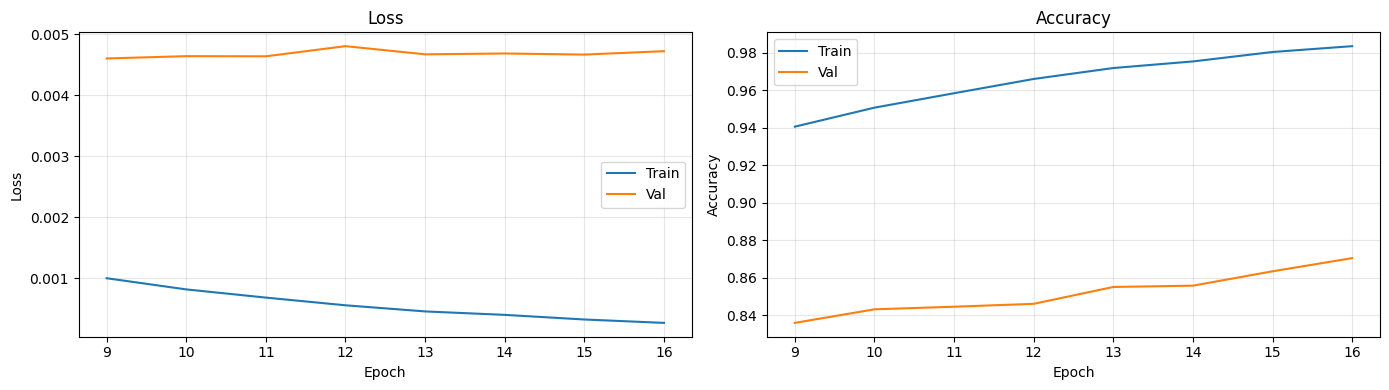

In [14]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train")
axes[1].plot(history_df["epoch"], history_df["val_acc"],   label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()